In [1]:
import os

In [2]:
print(os.cpu_count())

16


In [3]:
import numpy as np

In [4]:
SEIS_DIR = "/data/datasets/syn/seis"
s0 = np.fromfile(f"{SEIS_DIR}/0.dat",
                     dtype=np.float32)

In [5]:
s0.shape

(8388608,)

In [6]:
SEIS_DIR = "/data/datasets/syn/seis"
s0 = np.fromfile(f"{SEIS_DIR}/0.dat",
                     dtype=np.float32).reshape(256, 256, 128)

In [7]:
s0.shape

(256, 256, 128)

In [8]:
import os

In [9]:
seis_count = len(os.listdir(SEIS_DIR)) if os.path.exists(SEIS_DIR) else 0

In [10]:
print(f"\nSeismic samples : {seis_count}")


Seismic samples : 505


In [11]:
print(f"Seismic: {s0.shape}  range=[{s0.min():.3f}, {s0.max():.3f}]")

Seismic: (256, 256, 128)  range=[-7.594, 7.348]


In [12]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
import matplotlib.pyplot as plt

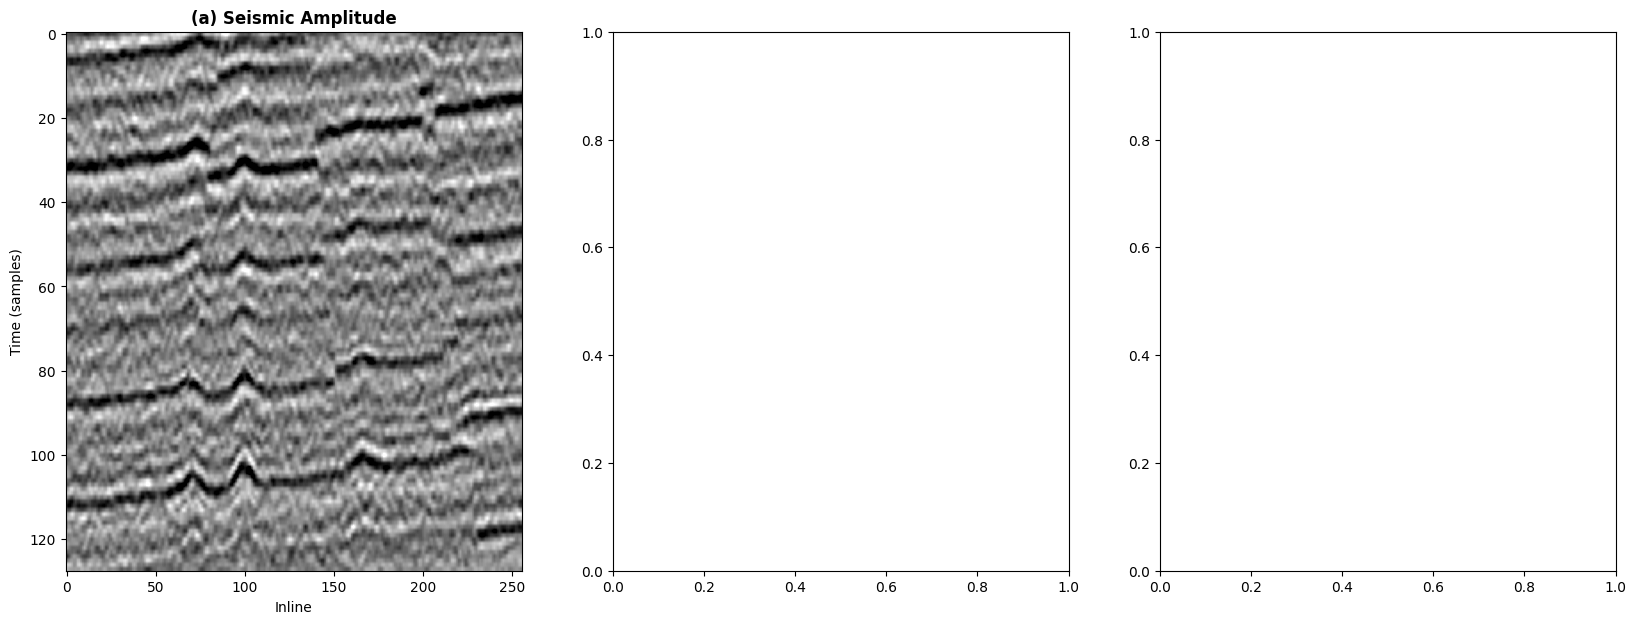

In [14]:
mid_il     = 128
clip       = np.percentile(np.abs(s0), 98)
rgt_levels = np.linspace(0.05, 0.95, 15)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel 1 — Seismic
axes[0].imshow(s0[:, 60, :].T, aspect="auto",
               cmap="gray", vmin=-clip, vmax=clip)
axes[0].set_title("(a) Seismic Amplitude", fontweight="bold")
axes[0].set_xlabel("Inline"); axes[0].set_ylabel("Time (samples)")
plt.show()


In [15]:
import sys

In [16]:
RGTNET   = f"/apps/rgtNet"

In [17]:
sys.path.insert(0, RGTNET)

In [18]:
!pip install torchsummary natsort scikit-image plotly tqdm -q

# Verify imports work
print("\nTesting imports ...")
try:
    import utils
    from models import net3d
    from data.dataloader import Dataset
    from data.augments import Reshape, ToTensor
    from lossf.loss import mse3DLoss, ssim3DLoss
    from lossf.metrics import Result, AverageMeter
    import draw
    print("All imports successful ✅")
except Exception as e:
    print(f"Import error: {e}")


Testing imports ...
All imports successful ✅


In [19]:
required_files = [
    "train.py",
    "infer.py",
    "draw.py",
    "utils.py",
    "train.sh",
    "infer.sh",
    "requirments.txt",
    "data/dataloader.py",
    "data/augments.py",
    "models/net3d.py",
    "models/modules3d.py",
    "models/rgt3d.py",
    "lossf/loss.py",
    "lossf/metrics.py",
    "lossf/ssim3d.py",
    "options/base_options.py",
    "options/train_options.py",
    "options/test_options.py",
]

print("Checking required files:")
all_ok = True
for f in required_files:
    path   = f"{RGTNET}/{f}"
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    status = "✅" if exists else "❌ MISSING"
    print(f"  {f:<40} {status}  ({size} bytes)")
    if not exists:
        all_ok = False

print(f"\n{'All files present ✅' if all_ok else '❌ Some files missing — re-run Cell 2'}")

Checking required files:
  train.py                                 ✅  (9388 bytes)
  infer.py                                 ✅  (5610 bytes)
  draw.py                                  ✅  (6299 bytes)
  utils.py                                 ✅  (2320 bytes)
  train.sh                                 ✅  (413 bytes)
  infer.sh                                 ✅  (188 bytes)
  requirments.txt                          ✅  (210 bytes)
  data/dataloader.py                       ✅  (1816 bytes)
  data/augments.py                         ✅  (1295 bytes)
  models/net3d.py                          ✅  (544 bytes)
  models/modules3d.py                      ✅  (6083 bytes)
  models/rgt3d.py                          ✅  (7959 bytes)
  lossf/loss.py                            ✅  (808 bytes)
  lossf/metrics.py                         ✅  (1994 bytes)
  lossf/ssim3d.py                          ✅  (10820 bytes)
  options/base_options.py                  ✅  (4528 bytes)
  options/train_options.py         

In [20]:
import os, shutil, random, json, glob

DATA_ROOT    = "/data/datasets/syn"
PROJECT      = "/data/RGT_Project"
TRAIN_DIR    = f"{PROJECT}/datasets/syn_train"
VAL_DIR      = f"{PROJECT}/datasets/syn_val"
TEST_DIR     = f"{PROJECT}/datasets/syn_test"
SESSIONS_DIR = f"{PROJECT}/train_sessions"
CKPT_DIR     = f"{PROJECT}/checkpoints"
OUTPUT_DIR   = f"{PROJECT}/outputs"

for d in [TRAIN_DIR+"/seis", TRAIN_DIR+"/rgt",
          VAL_DIR+"/seis",   VAL_DIR+"/rgt",
          TEST_DIR+"/seis",  TEST_DIR+"/rgt",
          SESSIONS_DIR, CKPT_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Project folder: {PROJECT} ✅")

Project folder: /data/RGT_Project ✅


In [21]:
# Get only .dat files
all_files = sorted(
    [f for f in os.listdir(f"{DATA_ROOT}/seis")
     if f.endswith(".dat")],
    key=lambda x: int(x.replace(".dat",""))
)
all_files = [f for f in all_files
             if os.path.exists(f"{DATA_ROOT}/rgt/{f}")]

total = len(all_files)
print(f"Valid pairs: {total}")

Valid pairs: 495


In [22]:
# Split
random.seed(42)
random.shuffle(all_files)

n_train = int(0.80 * total)
n_val   = int(0.10 * total)
n_test  = total - n_train - n_val

train_ids = all_files[:n_train]
val_ids   = all_files[n_train:n_train+n_val]
test_ids  = all_files[n_train+n_val:]

print(f"Train: {len(train_ids)}  Val: {len(val_ids)}  Test: {len(test_ids)}")

def copy_split(file_ids, split_dir, label):
    existing = len([f for f in os.listdir(f"{split_dir}/seis")
                    if f.endswith(".dat")])
    if existing == len(file_ids):
        print(f"{label}: already copied ✅")
        return
    print(f"Copying {label} ({len(file_ids)} files) ...")
    for new_idx, fname in enumerate(file_ids):
        shutil.copy(f"{DATA_ROOT}/seis/{fname}",
                    f"{split_dir}/seis/{new_idx}.dat")
        shutil.copy(f"{DATA_ROOT}/rgt/{fname}",
                    f"{split_dir}/rgt/{new_idx}.dat")
        if new_idx % 100 == 0:
            print(f"  {new_idx}/{len(file_ids)} ...")
    print(f"  {label} done ✅")

copy_split(train_ids, TRAIN_DIR, "TRAIN")
copy_split(val_ids,   VAL_DIR,   "VAL")
copy_split(test_ids,  TEST_DIR,  "TEST")

with open(f"{PROJECT}/split_info.json", 'w') as f:
    json.dump({"train": train_ids,
               "val"  : val_ids,
               "test" : test_ids}, f, indent=2)
print("Split saved ✅")

Train: 396  Val: 49  Test: 50
TRAIN: already copied ✅
VAL: already copied ✅
TEST: already copied ✅
Split saved ✅


In [23]:
!pip install matplotlib numpy Pillow plotly pyparsing scikit-image scikit-learn scipy torch torchsummary torchvision tqdm -q


In [24]:
RGTNET = "/apps/rgtNet"

with open(f"{RGTNET}/train.py", 'r') as f:
    content = f.read()


# Fix 2 — Use loss.item() instead of float(loss)
content = content.replace(
    "running_loss += float(loss)",
    "running_loss += loss.item()"
)

# Fix 3 — Fix validation epoch condition
# valid_interval=4 means validate at epoch 4,8,12...
# but epoch 0 also validates which is confusing
# change to: validate at end of every valid_interval epochs
#content = content.replace(
#    "if opt.valid and epoch % opt.valid_interval == 0:",
#    "if opt.valid and (epoch + 1) % opt.valid_interval == 0:"
#)

with open(f"{RGTNET}/train.py", 'w') as f:
    f.write(content)

print("train.py fixed ✅")
print(f"Anomaly detection removed : {'detect_anomaly' not in content}")
print(f"loss.item() fix applied   : {'loss.item()' in content}")
print(f"Validation epoch fix      : {'(epoch + 1) %' in content}")

train.py fixed ✅
Anomaly detection removed : True
loss.item() fix applied   : True
Validation epoch fix      : True


In [ ]:
import subprocess, torch, gc

torch.cuda.empty_cache()
gc.collect()

# Check for checkpoint
checkpoints = sorted(
    glob.glob(f"{SESSIONS_DIR}/**/checkpoint/*.pth",
              recursive=True),
    key=lambda p: int(os.path.basename(p).replace(".pth",""))
)
last_ckpt  = checkpoints[-1] if checkpoints else None
last_epoch = int(os.path.basename(last_ckpt).replace(".pth","")) \
             if last_ckpt else 0

print(f"Resume from epoch : {last_epoch}")

cmd = [
    "python3", f"{RGTNET}/train.py",
    "--dataroot",            TRAIN_DIR,
    "--dataroot_val",        VAL_DIR,
    "--shape",               "200", "200", "128",  # fits in 24GB
    "--batch_size",          "1",
    "--nepochs",             "100",
    "--lr",                  "0.0002",
    "--weight_decay",        "1e-4",
    "--num_workers",         "8",
    "--loss_type",           "SSIM",
    "--data_augmentation",   "n",
    "--dataset_size",        str(len(train_ids)),
    "--valid",               "y",
    "--dataset_size_val",    str(len(val_ids)),
    "--valid_interval",      "1",
    "--checkpoint_interval", "2",
    "--history_interval",    "1",
    "--sessions_path",       SESSIONS_DIR,
    "--gpu_ids",             "0",
    "--lr_patience",         "3",
    "--lr_factor",           "0.5",
]

if last_ckpt:
    cmd += ["--pretrained_model", last_ckpt]

print(f"Shape   : 200×200×128 (cropped from 256×256×128)")
print(f"Train   : {len(train_ids)} samples")
print(f"Val     : {len(val_ids)} samples")
print(f"Augment : OFF")
print(f"Epochs  : 100\n")

process = subprocess.Popen(
    cmd, cwd=RGTNET,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True, bufsize=1
)

for line in process.stdout:
    print(line, end='', flush=True)

process.wait()
print(f"\nReturn code: {process.returncode}")
print("Done ✅" if process.returncode == 0 else "Failed ❌")


Resume from epoch : 20
Shape   : 200×200×128 (cropped from 256×256×128)
Train   : 396 samples
Val     : 49 samples
Augment : OFF
Epochs  : 100

					TRAIN OPTIONS
               batch_size: 1                             
      checkpoint_interval: 2                             	[default: 100]
         checkpoints_path: ./checkpoints                 
        data_augmentation: False                         	[default: True]
                 dataroot: /data/RGT_Project/datasets/syn_train	[default: None]
             dataroot_val: /data/RGT_Project/datasets/syn_val	[default: None]
             dataset_size: 396                           	[default: inf]
         dataset_size_val: 49                            	[default: inf]
                  gpu_ids: 0                             
         history_interval: 1                             	[default: 50]
                  isTrain: True                          	[default: None]
                loss_type: SSIM                          	[default

In [53]:
import numpy as np
import torch, gc, os, sys, glob

RGTNET  = "/apps/rgtNet"
PROJECT = "/data/RGT_Project"
sys.path.insert(0, RGTNET)

In [55]:
sys.path.insert(0, RGTNET)

from models import net3d
from data.augments import Reshape, ToTensor, CropVolume
from torchvision import transforms
import utils

# ── Load best checkpoint ──────────────────────────────────────────────────────
SESSIONS_DIR = f"{PROJECT}/train_sessions"
checkpoints = sorted(
    glob.glob(f"{SESSIONS_DIR}/**/checkpoint/*.pth",
              recursive=True),
    key=lambda p: int(os.path.basename(p).replace(".pth",""))
)
best_ckpt  = checkpoints[-5]
last_epoch = os.path.basename(best_ckpt).replace(".pth","")
print(f"Using checkpoint: epoch {last_epoch}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = net3d.model({
    'input_channels'  : 1,
    'encoder_channels': 512,
    'decoder_channels': 16
}).to(device)

model.load_state_dict(
    torch.load(best_ckpt, map_location=device)
)
model.eval()
print(f"Model loaded ✅")



Using checkpoint: epoch 90
Model loaded ✅


In [68]:
# ── Load one sample ───────────────────────────────────────────────────────────
TEST_SEIS = f"{PROJECT}/datasets/syn_test/seis"
TEST_RGT  = f"{PROJECT}/datasets/syn_test/rgt"

# Use sample 0
transform = transforms.Compose([
    Reshape((256, 256, 128, 1)),
    CropVolume((200, 200, 128, 1)),
    ToTensor(),
])

seis_raw = np.fromfile(f"{TEST_SEIS}/12.dat", dtype=np.float32)
rgt_raw  = np.fromfile(f"{TEST_RGT}/12.dat",  dtype=np.float32)

seis_t = transform(seis_raw)
rgt_t  = transform(rgt_raw)

# Normalize as dataloader does
def mea_std_norm(x):
    return (x - x.mean()) / x.std()

seis_t = torch.from_numpy(mea_std_norm(seis_t))
rgt_t  = torch.from_numpy(mea_std_norm(rgt_t))

print(f"Seis tensor: {seis_t.shape}")
print(f"RGT tensor : {rgt_t.shape}")

# ── Run inference ─────────────────────────────────────────────────────────────
with torch.no_grad():
    seis_input = seis_t.unsqueeze(0).to(device)  # (1,1,128,128,128)
    rgt_pred   = model(seis_input)
    rgt_pred   = rgt_pred.squeeze().cpu().numpy()  # (128,128,128)

seis_np = seis_t.squeeze().numpy()   # (128,128,128)
rgt_np  = rgt_t.squeeze().numpy()    # (128,128,128)

print(f"Prediction range: [{rgt_pred.min():.4f}, {rgt_pred.max():.4f}]")
print(f"Truth range     : [{rgt_np.min():.4f}, {rgt_np.max():.4f}]")

Seis tensor: torch.Size([1, 128, 200, 200])
RGT tensor : torch.Size([1, 128, 200, 200])
Prediction range: [-2.2225, 2.8443]
Truth range     : [-2.7164, 2.6068]


In [60]:
%matplotlib inline

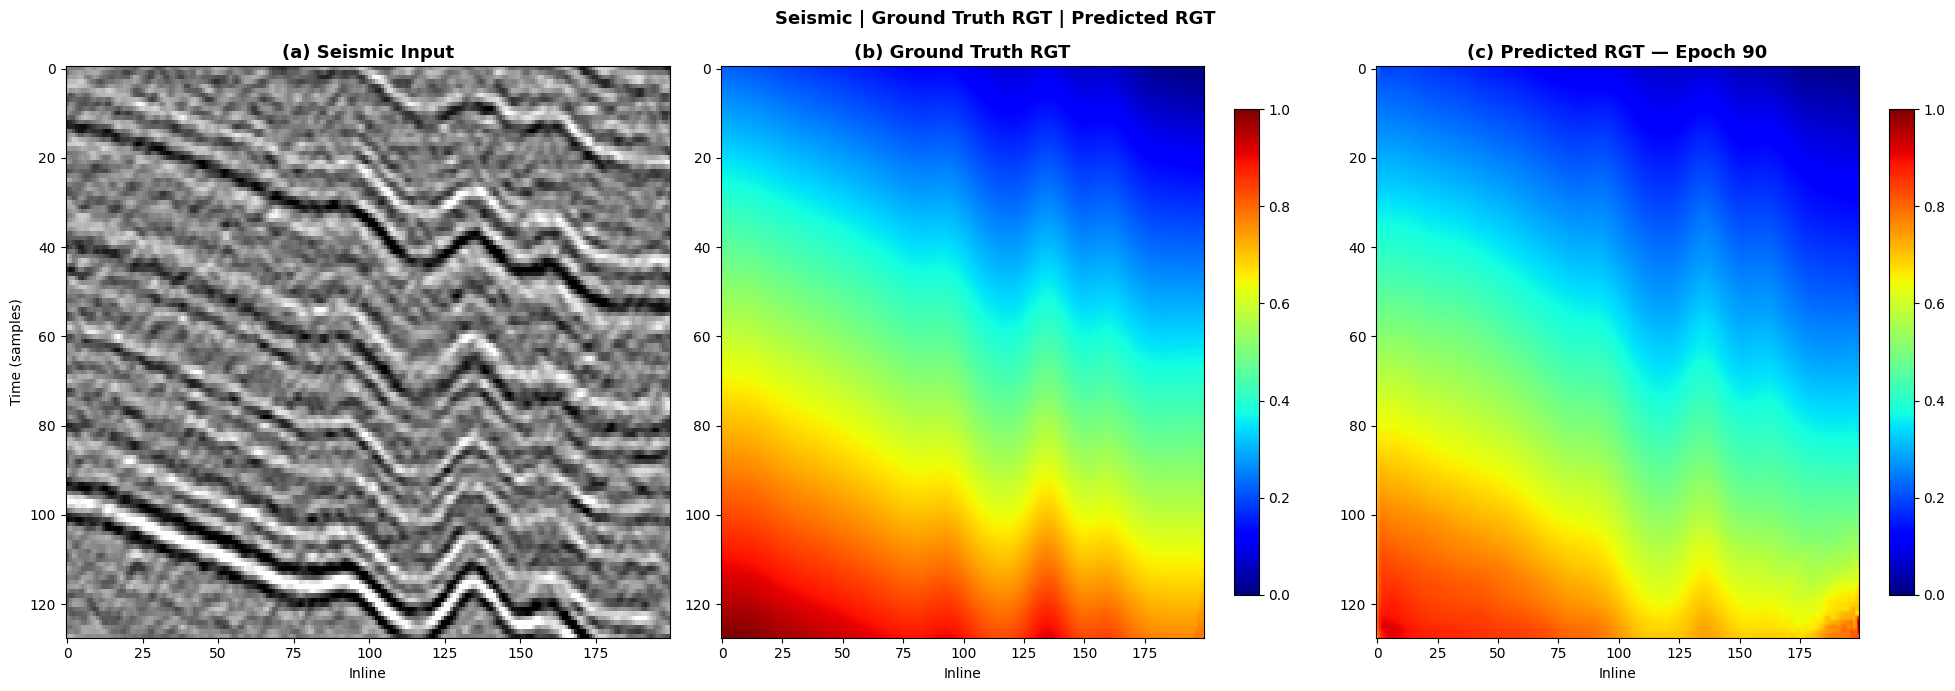

Figure displayed and saved ✅


In [69]:
# Now re-run the visualization
import numpy as np

mid  = 64
clip = np.percentile(np.abs(seis_np[:, mid, :]), 98)

def norm_display(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

seis_show     = seis_np[:, mid, :]
rgt_true      = norm_display(rgt_np[:, mid, :])
rgt_pred_show = norm_display(rgt_pred[:, mid, :])

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(seis_show, aspect="auto",
               cmap="gray", vmin=-clip, vmax=clip)
axes[0].set_title("(a) Seismic Input",
                  fontweight="bold", fontsize=13)
axes[0].set_xlabel("Inline")
axes[0].set_ylabel("Time (samples)")

im1 = axes[1].imshow(rgt_true, aspect="auto",
                     cmap="jet", vmin=0, vmax=1)
axes[1].set_title("(b) Ground Truth RGT",
                  fontweight="bold", fontsize=13)
axes[1].set_xlabel("Inline")
plt.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(rgt_pred_show, aspect="auto",
                     cmap="jet", vmin=0, vmax=1)
axes[2].set_title(f"(c) Predicted RGT — Epoch {last_epoch}",
                  fontweight="bold", fontsize=13)
axes[2].set_xlabel("Inline")
plt.colorbar(im2, ax=axes[2], shrink=0.85)

plt.suptitle(
    "Seismic | Ground Truth RGT | Predicted RGT",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{PROJECT}/outputs/prediction_vs_truth.png",
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Figure displayed and saved ✅")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

contour_levels = np.linspace(0.1, 0.9, 10)

# Left — seismic + truth contours
axes[0].imshow(seis_show, aspect="auto",
               cmap="gray", vmin=-clip, vmax=clip)
axes[0].contour(rgt_true, levels=contour_levels,
                cmap="jet", linewidths=1.5, alpha=0.9)
axes[0].set_title("Seismic + Ground Truth Horizons",
                  fontweight="bold", fontsize=12)
axes[0].set_xlabel("Inline")
axes[0].set_ylabel("Time (samples)")

# Right — seismic + predicted contours
axes[1].imshow(seis_show, aspect="auto",
               cmap="gray", vmin=-clip, vmax=clip)
axes[1].contour(rgt_pred_show, levels=contour_levels,
                cmap="jet", linewidths=1.5, alpha=0.9)
axes[1].set_title(f"Seismic + Predicted Horizons (epoch {last_epoch})",
                  fontweight="bold", fontsize=12)
axes[1].set_xlabel("Inline")
axes[1].set_ylabel("Time (samples)")

plt.suptitle(
    "Horizon Comparison — Ground Truth vs Prediction\n"
    "Each contour line = one RGT isosurface = one horizon",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{PROJECT}/outputs/horizon_comparison.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved ✅")

In [2]:
!pip install pandas -q

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Update this path to match your actual directory
history_dir = "/data/RGT_Project/train_sessions/Mar28_093250_Train/history"

# Load the files
train_df = pd.read_csv(os.path.join(history_dir, "train_history.txt"))
test_df = pd.read_csv(os.path.join(history_dir, "test_history.txt"))


In [26]:
history_path = "/data/RGT_Project/train_sessions/Mar28_093250_Train/history/train_history.txt"

train_df = pd.read_csv(history_path, sep='\s+')


In [27]:
train_df.head()

,EPOCH,SSIM,LR
0,0,0.091734,0.0002
1,1,0.084006,0.0002
2,2,0.077619,0.0002
3,3,0.058351,0.0002
4,4,0.048461,0.0002


In [30]:
test_df = pd.read_csv("/data/RGT_Project/train_sessions/Mar28_093250_Train/history/test_history.txt", sep='\s+')


In [31]:
test_df.head()

,EPOCH,MAE,MSE,RMSE,MRPD,SSIM
0,0,0.374385,0.225136,0.457582,0.667716,0.077504
1,1,0.369490,0.220552,0.451544,0.660432,0.076472
2,2,0.325575,0.176448,0.405214,0.605083,0.071297
3,3,0.235167,0.098870,0.301106,0.477326,0.053062
4,4,0.239270,0.102579,0.302490,0.487059,0.053064


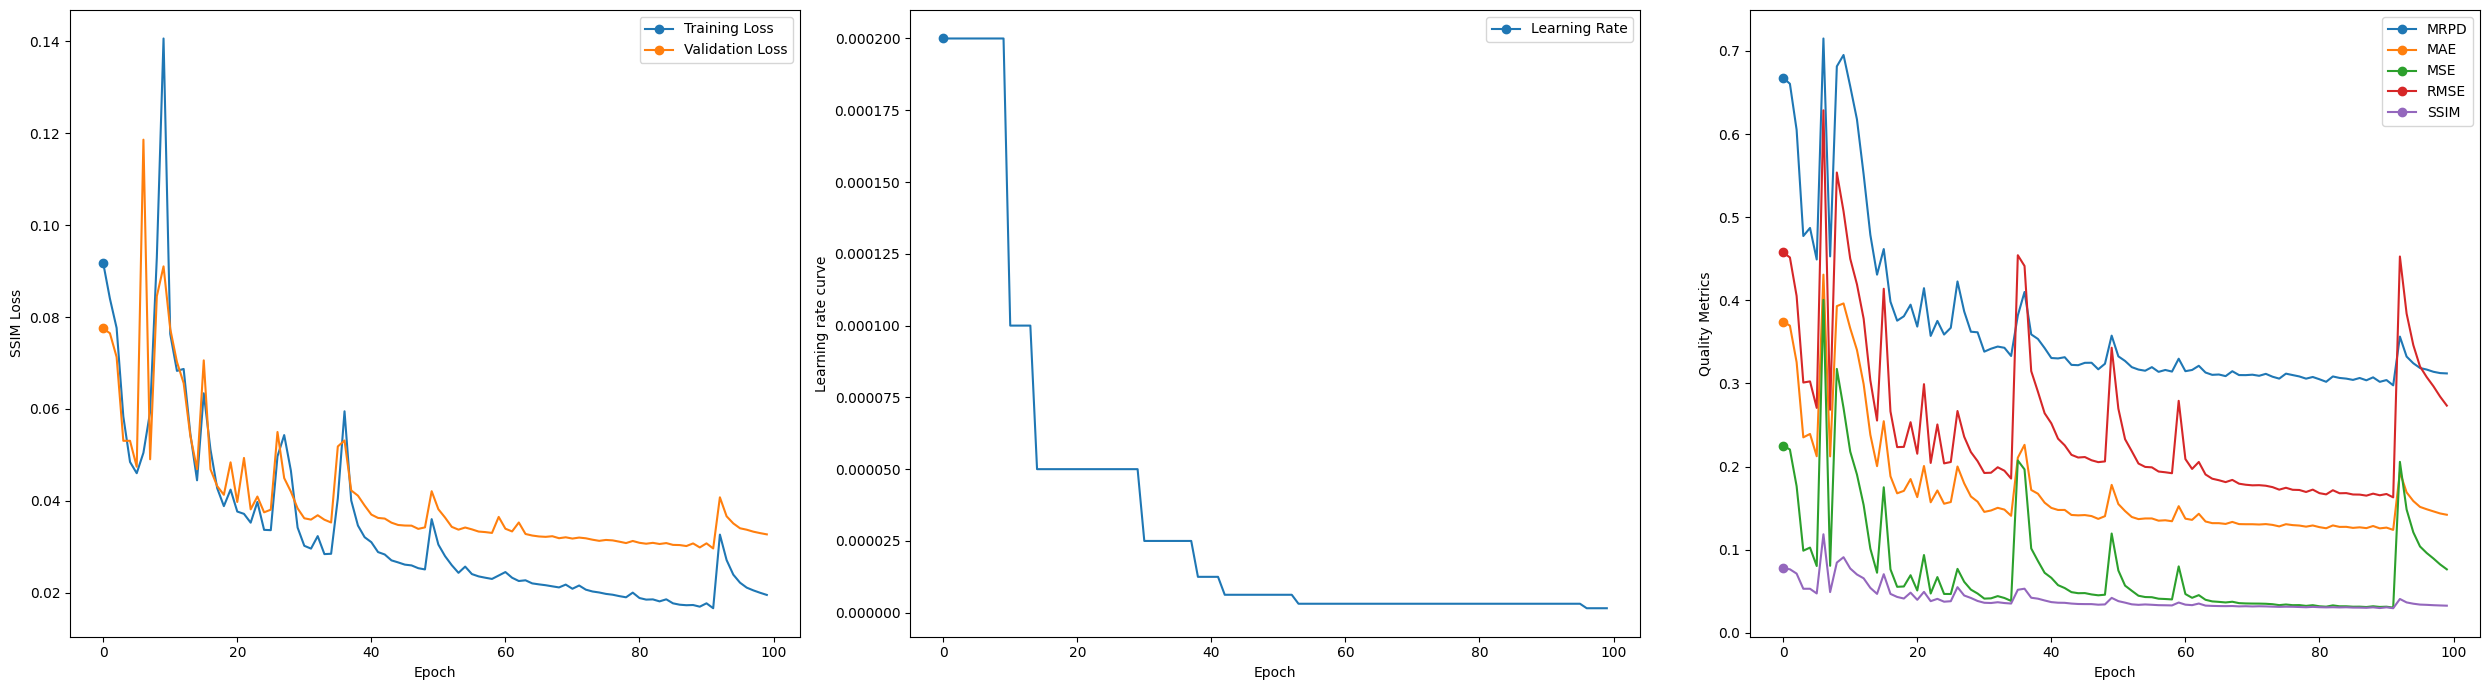

In [51]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize=(25,7))
axs[0].plot(train_df['EPOCH'],train_df['SSIM'],marker='o', label='Training Loss',markevery=[0])
axs[0].plot(test_df['EPOCH'], test_df['SSIM'],marker='o', label='Validation Loss',markevery=[0])
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('SSIM Loss')
axs[0].legend()

axs[1].plot(train_df['EPOCH'], train_df['LR'],marker='o', label='Learning Rate',markevery=[0])
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Learning rate curve')
axs[1].legend()

axs[2].plot(test_df['EPOCH'],test_df['MRPD'],marker='o', label='MRPD',markevery=[0])
axs[2].plot(test_df['EPOCH'],test_df['MAE'],marker='o', label='MAE',markevery=[0])
axs[2].plot(test_df['EPOCH'],test_df['MSE'],marker='o', label='MSE',markevery=[0])
axs[2].plot(test_df['EPOCH'],test_df['RMSE'],marker='o', label='RMSE',markevery=[0])
axs[2].plot(test_df['EPOCH'],test_df['SSIM'],marker='o', label='SSIM',markevery=[0])
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Quality Metrics')
axs[2].legend()

plt.tight_layout()
plt.savefig("Training and Validation parameters.png",
            dpi=150)
plt.show()